In [1]:
from scipy.stats import norm
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from class_imbalance_experiment.util import run_experiment, multiclass_imbalance_ratio

# Seed for reproducibility
np.random.seed(42)

# Number of samples
n_samples = 10000

# Class distribution (most in 1)
class_distribution = [0.8, 0.07, 0.055, 0.045, 0.03]
classes = np.arange(1, 6)

le = LabelEncoder()
le.fit(classes)


# Latent variable
z = np.random.normal(0, 1.0, n_samples)

# Find thresholds according to distribution
cum_probs = np.cumsum(class_distribution)
thresholds = np.concatenate(([-np.inf],norm.ppf(cum_probs)))
print(thresholds)

y = np.searchsorted(thresholds, z, side="right")

# Generate ordinal target
#y = np.random.choice(classes, size=n_samples, p=class_distribution)



print("Imbalance Ratio (IR) ", multiclass_imbalance_ratio(y))

# Create features
X1 = z + np.random.normal(0, 1.0, n_samples)
X2 = np.sin(z) + np.random.normal(0, 1.0, n_samples)
X3 = 0.8 * z + np.random.normal(0, 0.2, n_samples)
X4 = 0.5 * z + np.random.normal(0, 0.3, n_samples)

# # Create overlapping features
# # These have weak correlation to the class to keep accuracy moderate (<90%)
# X1 = y + np.random.normal(0, 1.0, n_samples)  # noisy ordinal relation
# X2 = np.sin(y) + np.random.normal(0, 1.0, n_samples)  # nonlinear but correlated
# X3 = np.random.normal(0, 1.0, n_samples)  # mostly noise
# X4 = 0.5 * y + np.random.normal(0, 1.0, n_samples)

# Combine into a DataFrame
data = pd.DataFrame({
    'feature_1': X1,
    'feature_2': X2,
    'feature_3': X3,
    'feature_4': X4,
    'class': y
})

# Assuming `data` DataFrame exists
X = data.drop(columns='class')
y = data['class']







[      -inf 0.84162123 1.12639113 1.43953147 1.88079361        nan]
[      -inf 0.84162123 1.12639113 1.43953147 1.88079361        nan]
Imbalance Ratio (IR)  26.249180327868853


In [2]:
# Overall class distribution
print("\nClass distribution in full dataset:")
print(data['class'].value_counts(normalize=True).sort_index().values)


Class distribution in full dataset:
[0.8006 0.0683 0.055  0.0456 0.0305]


C:\Users\Q454199\projects\ordinal-aleatoric-epistemic-uncertainty\class_imbalance_experiment\util.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(x=[1,2,3,4,5],y=p,legend=False,palette=colors)


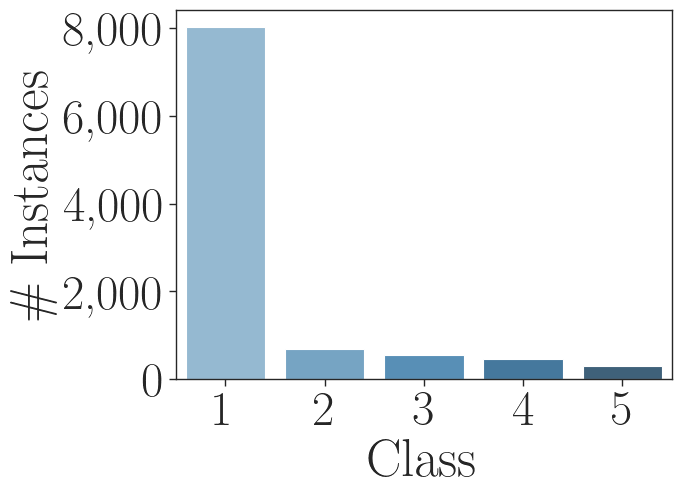

In [5]:
from class_imbalance_experiment.util import plot_data_dist

plot_data_dist(data['class'].value_counts(normalize=False).sort_index().values , "right_tail")

In [4]:
run_experiment(X, y, le, "right_tail")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000174 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 9000, number of used features: 4
[LightGBM] [Info] Start training from score -0.222449
[LightGBM] [Info] Start training from score -2.683358
[LightGBM] [Info] Start training from score -2.900422
[LightGBM] [Info] Start training from score -3.088823
[LightGBM] [Info] Start training from score -3.488209
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 9000, number of used features: 4
[Light